# Replicating *Modular Dynamics of Financial Market Networks*

Silva, Comin, Peron, Rodrigues, Ye, Wilson, Hancock & Costa (2015) — [arXiv:1501.05040v3](https://arxiv.org/abs/1501.05040)

**This notebook does one thing: it runs what the paper says it ran, and compares the numbers to the paper's.**
Nothing has been added, corrected, or extended. Where the paper leaves a step unspecified, one reading is
chosen, said out loud, and used everywhere.

## What the paper claims, in plain words

Take 25 years of daily stock prices. Every day, look back 30 days and measure how similarly each pair of
stocks moved. Keep only the 10% strongest pairs — that gives you one network per day, where stocks are
dots and a line means "these two moved together recently".

Each day, find the **communities** in that network: groups of stocks that connect to each other more than
to everyone else. Now throw the network away. Keep only two things:

- how big each community was, and
- how many links ran between each pair of communities (the *mixing matrix*, written Π).

From those two numbers alone, build a brand-new random network. The paper's claim is that this rebuilt
network looks a lot like the real one — same path lengths, same clustering, same everything — which would
mean the community structure alone carries almost all the information in the market network.

To know whether "a lot like" is impressive, you need something to compare against. The paper uses a
second, simpler random network that keeps only each stock's **number of connections** and shuffles the
rest. If the community version matches the real network better than this one does, the community
structure is telling us something the raw connection counts are not.

Finally: during crises the network is supposed to lose its community structure and become more uniform.

## How to read this notebook

**Before running:** this notebook needs `python-igraph` and `pyarrow`, both listed in the project's
`requirements.txt`. If the first cell fails with `No module named 'igraph'`, the kernel you picked
does not have them — install with `pip install -r requirements.txt`.

Ten steps, in the paper's own order. Every figure is a reproduction of a specific figure in the paper,
and the final table puts all 32 of the paper's published numbers next to ours.

In [1]:
import json, os, random, sys, warnings
import numpy as np, pandas as pd
import igraph as ig
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = os.path.abspath(".")
sys.path.insert(0, ROOT); sys.path.insert(0, os.path.join(ROOT, "experiments"))
warnings.filterwarnings("ignore")

import exp_paper_only as P
from net.construct import (log_returns, window_correlation, target_edge_count,
                           threshold_window, decode_pairs)
from net.communities import (graph_from_pairs, mixing_matrix, edge_endpoints,
                             community_sizes, MixingStore)
from net.nullmodels import block_probabilities, community_graph, configuration_graph

# the paper's own colour scheme: inferred = blue, community = orange, degree = green
C_REAL, C_COMM, C_CONF = "#1f4e9c", "#e08214", "#2f8f4e"
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})

def load(name): return json.load(open(os.path.join(ROOT, "results", name)))
print("ready")

ready


---
## Step 1 — The data

The paper: *"daily prices of 3799 stocks traded on the New York Stock Exchange... We selected N = 348
stocks... for which there are historical data from January 1986 to February 2011. For these stocks, we
obtained C_p = 6008 closure prices per stock."*

We cannot use the paper's exact list. It was a snapshot of NYSE listings as of 2015, and that list no
longer exists — today's directories only contain companies that are *still listed*, so our starting pool
is smaller but its survivors are, by definition, the ones with a complete 25-year history. This is the
one difference we cannot close, and everything downstream inherits it.

In [2]:
p0, p1 = load("phase0_universe.json"), load("phase1_returns.json")
tbl = pd.DataFrame({
    "the paper": ["3,799 NYSE stocks", "348", "Jan 1986 – Feb 2011", "6,008", "5,978"],
    "this run":  [f"{p0['n_candidates']:,} NYSE candidates", f"{p1['n_tickers']}",
                  f"{p0['panel_start']} – {p0['panel_end']}", f"{p0['n_days_final']:,}",
                  f"{p0['n_windows']:,}"],
}, index=["starting pool", "stocks used (N)", "period", "trading days (C_p)", "networks (N_w = C_p − 30)"])
print(tbl.to_string())
print(f"\nSo we have {p1['n_tickers']} stocks instead of 348, and {p0['n_windows']:,} daily networks "
      f"instead of 5,978.\nSame market, same quarter-century, a slightly different and slightly larger sample.")

                                     the paper                 this run
starting pool                3,799 NYSE stocks      985 NYSE candidates
stocks used (N)                            348                      360
period                     Jan 1986 – Feb 2011  1986-01-02 – 2011-02-28
trading days (C_p)                       6,008                    6,345
networks (N_w = C_p − 30)                5,978                    6,315

So we have 360 stocks instead of 348, and 6,315 daily networks instead of 5,978.
Same market, same quarter-century, a slightly different and slightly larger sample.


---
## Step 2 — From prices to a network, one day at a time

Three operations, each one throwing information away.

**1. Returns.** Instead of the price, use the daily log return: `Y_i(t) = ln P_i(t) − ln P_i(t−1)`.
This is just "how much did the stock move today", and it makes stocks of different price levels comparable.

**2. Similarity (the paper's Eq. 1).** For every pair of stocks, take the Pearson correlation of their
returns over the last 30 days. Correlation near 1 means they moved together; near 0, unrelated.

**3. Threshold.** Keep only the strongest 10% of pairs as links. Note what this means: the cutoff value is
*re-solved every single day* so that exactly 10% of pairs survive. The market can become more or less
correlated overall and the network will not notice — it always has the same number of links.

Below, the whole procedure on one day.

In [3]:
prices = pd.read_parquet(os.path.join(ROOT, "data", "panel_clean.parquet"))
returns = np.load(os.path.join(ROOT, "data", "returns.npy"))
N = returns.shape[0]
DELTA_T, F = 30, 0.10

w = 1200                                   # an ordinary day, well away from any crisis
C = window_correlation(returns, w, DELTA_T)                 # step 2: all pairwise correlations
n_edges = target_edge_count(N, F)                           # step 3: how many links to keep
tau, pairs, weights = threshold_window(C, n_edges, np.triu_indices(N, 1))
g = graph_from_pairs(pairs, N)
date = prices.index[w + DELTA_T]

print(f"day {date.date()}")
print(f"  pairs of stocks               {N*(N-1)//2:,}")
print(f"  links kept (10%)              {g.ecount():,}")
print(f"  correlation cutoff that day   {tau:.3f}")
print(f"  average links per stock       {2*g.ecount()/N:.2f}   (= 0.10 x (N-1) = {F*(N-1):.2f})")
print(f"  stocks left with no links     {sum(d == 0 for d in g.degree())}")

day 1990-11-12
  pairs of stocks               64,620
  links kept (10%)              6,462
  correlation cutoff that day   0.422
  average links per stock       35.90   (= 0.10 x (N-1) = 35.90)
  stocks left with no links     6


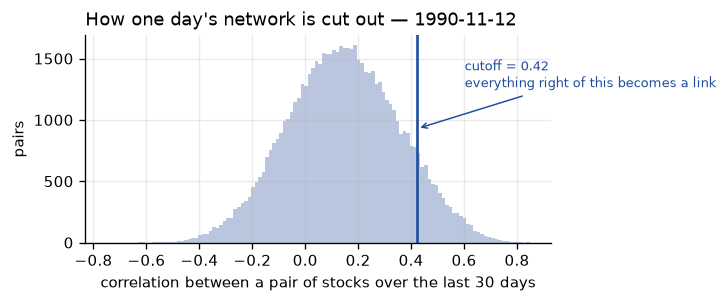

In [4]:
fig, ax = plt.subplots(figsize=(6, 2.6))
vals = C[np.triu_indices(N, 1)]
ax.hist(vals, bins=120, color="#b9c6de", edgecolor="none")
ax.axvline(tau, color=C_REAL, lw=1.6)
ax.annotate(f"cutoff = {tau:.2f}\neverything right of this becomes a link",
            xy=(tau, ax.get_ylim()[1]*.55), xytext=(tau+.18, ax.get_ylim()[1]*.75),
            fontsize=8, color=C_REAL, arrowprops=dict(arrowstyle="->", color=C_REAL, lw=.9))
ax.set_xlabel("correlation between a pair of stocks over the last 30 days")
ax.set_ylabel("pairs"); ax.set_title(f"How one day's network is cut out — {date.date()}", loc="left")
plt.tight_layout(); plt.show()

In [5]:
p2 = load("phase2_networks.json")
print("Doing that for every day of the sample:")
print(f"  networks built              {p2['n_windows']:,}")
print(f"  links in every network      {p2['n_edges_per_day']:,}  (identical by construction)")
print(f"  average links per stock     {p2['mean_degree']:.4f}  (target {p2['mean_degree_target']:.4f})")
print(f"  the daily cutoff ranged     {p2['tau_min']:.3f} to {p2['tau_max']:.3f}"
      f"   (highest on {p2['tau_argmax_date']})")

Doing that for every day of the sample:
  networks built              6,315
  links in every network      6,462  (identical by construction)
  average links per stock     35.9000  (target 35.9000)
  the daily cutoff ranged     0.263 to 0.861   (highest on 1987-10-19)


---
## Step 3 — Communities, and what happens in a crash

Each day the paper runs the **Louvain** algorithm (it calls it "multilevel") to split the network into
communities. The quality of a split is its **modularity** `Q`: how many more links fall inside communities
than you would expect by chance. Higher Q = more clearly separated groups. Stocks that are completely
disconnected are counted as their own one-member community.

The paper's Fig. 3 shows what happened around Black Monday, 19 October 1987 — the one crisis it dates
exactly. Before the crash the market splits into two clear blocks. During it, that structure disappears:
almost every stock is dragged by the same panic, so nothing looks like a distinct group any more, and
most stocks end up with no strong links at all.

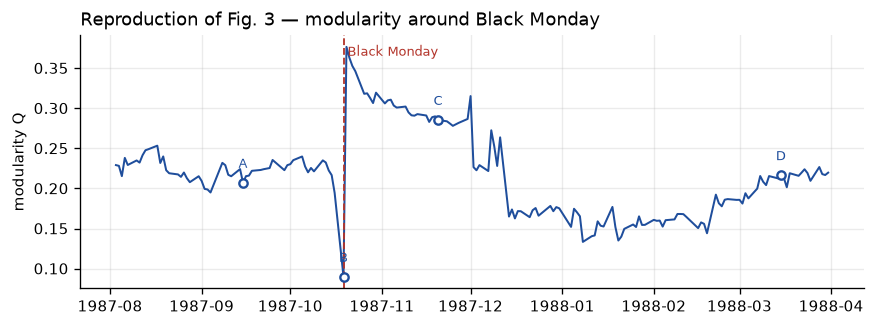

lowest modularity of the whole 25 years : 0.0897 on 1987-10-19
typical day                             : 0.2199
communities on Black Monday             : 156   (typical day: 9)


In [6]:
com = pd.read_parquet(os.path.join(ROOT, "results", "series", "communities.parquet"))
idx = com.index
BM = pd.Timestamp("1987-10-19")

sel = (idx >= "1987-08-01") & (idx <= "1988-03-31")
fig, ax = plt.subplots(figsize=(7.4, 2.8))
ax.plot(idx[sel], com["q_dyn"][sel], color=C_REAL, lw=1.2)
ax.axvline(BM, color="#b3352b", lw=1.1, ls="--")
ax.text(BM, ax.get_ylim()[1]*.97, " Black Monday", color="#b3352b", fontsize=8, va="top")
snaps = [("A  before", "1987-09-15"), ("B  during", "1987-10-19"),
         ("C  after", "1987-11-20"), ("D  far away", "1988-03-15")]
for lab, d in snaps:
    t = idx[idx.get_indexer([pd.Timestamp(d)], method="nearest")[0]]
    ax.plot([t], [com.loc[t, "q_dyn"]], "o", ms=5, mfc="white", mec=C_REAL, mew=1.4)
    ax.annotate(lab.split()[0], (t, com.loc[t, "q_dyn"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8, color=C_REAL)
ax.set_ylabel("modularity Q"); ax.set_title("Reproduction of Fig. 3 — modularity around Black Monday", loc="left")
plt.tight_layout(); plt.show()

print(f"lowest modularity of the whole 25 years : {com['q_dyn'].min():.4f} on "
      f"{com['q_dyn'].idxmin().date()}")
print(f"typical day                             : {com['q_dyn'].median():.4f}")
print(f"communities on Black Monday             : {int(com.loc[BM,'k'])}   "
      f"(typical day: {int(com['k'].median())})")

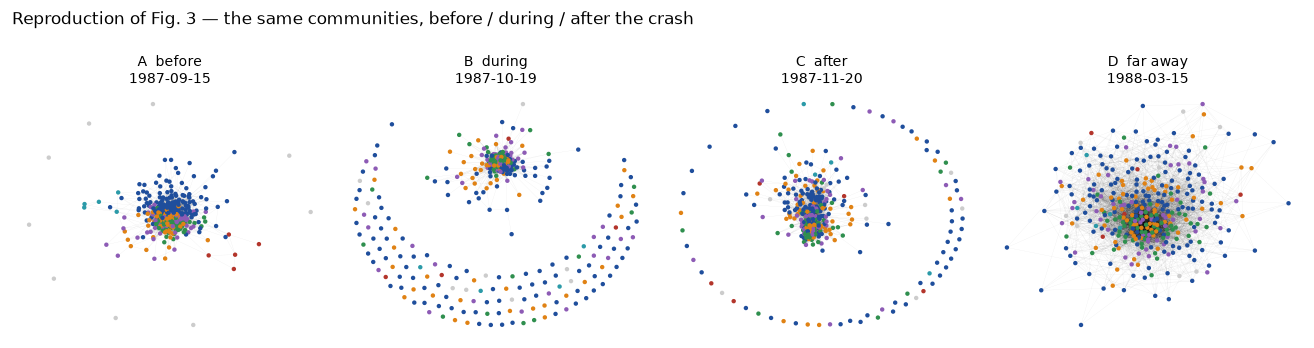

In [7]:
# the paper's four network pictures: communities are found in panel A only and the
# colours are then held fixed, so you can watch the same groups fall apart
edges = np.load(os.path.join(ROOT, "data", "edges.npy"), mmap_mode="r")
random.seed(42); ig.set_random_number_generator(random)
pos_of = {d: int(np.flatnonzero(idx == idx[idx.get_indexer([pd.Timestamp(d)], method='nearest')[0]])[0])
          for _, d in snaps}
gA = graph_from_pairs(edges[pos_of[snaps[0][1]]], N)
memb = np.asarray(gA.community_multilevel().membership)
big = pd.Series(memb).value_counts().index[:6]
palette = ["#1f4e9c", "#e08214", "#2f8f4e", "#8d5bb5", "#b3352b", "#2b9aa8"]
colour = [palette[list(big).index(m)] if m in list(big) else "#cccccc" for m in memb]

fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
for ax, (lab, d) in zip(axes, snaps):
    gg = graph_from_pairs(edges[pos_of[d]], N)
    lay = np.asarray(gg.layout_fruchterman_reingold(niter=200).coords)
    for e in gg.get_edgelist():
        ax.plot(lay[[e[0], e[1]], 0], lay[[e[0], e[1]], 1], color="#000000", lw=.12, alpha=.10, zorder=1)
    ax.scatter(lay[:, 0], lay[:, 1], s=7, c=colour, linewidths=0, zorder=2)
    ax.set_title(f"{lab}\n{idx[pos_of[d]].date()}", fontsize=8.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
plt.suptitle("Reproduction of Fig. 3 — the same communities, before / during / after the crash",
             x=.01, ha="left", fontsize=10)
plt.tight_layout(); plt.show()

### The paper's Fig. 4 and Fig. 5

Fig. 4 puts modularity and average path length across the whole 25 years with the known crises marked.
The paper names 17 crises but publishes an exact date for only one of them (Black Monday), so the bands
below are the conventional dates for those events; treat their edges as approximate, as the paper says.

Fig. 5 asks a follow-up question. Modularity can move for two different reasons: the groups themselves
changed, or the same groups became more or less tightly knit. To separate them the paper measures Q three
ways using the same formula and three different groupings —

- **dynamical**: re-find the communities every day,
- **fixed**: find them once on day 1 and never again,
- **lagged**: use the communities from 100 trading days ago.

If the fixed and lagged curves stay near the dynamical one, the groups are stable and only their density
is moving. If they fall away, the membership itself is churning.

**This is the one figure that does not come out like the paper's**, so it is worth looking at closely.

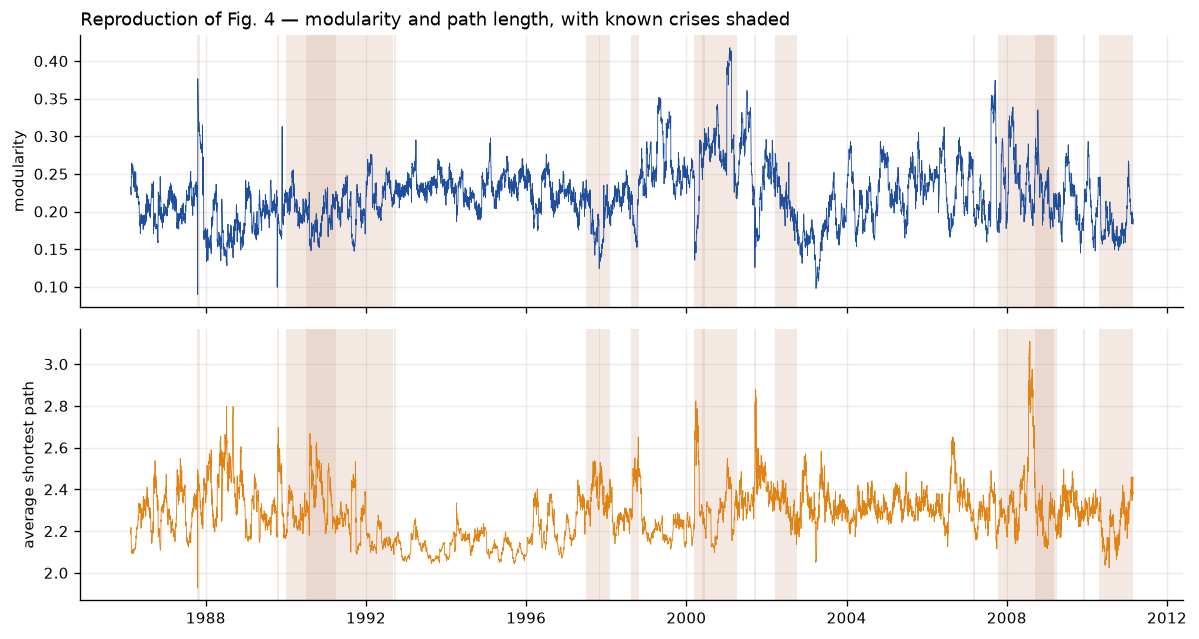

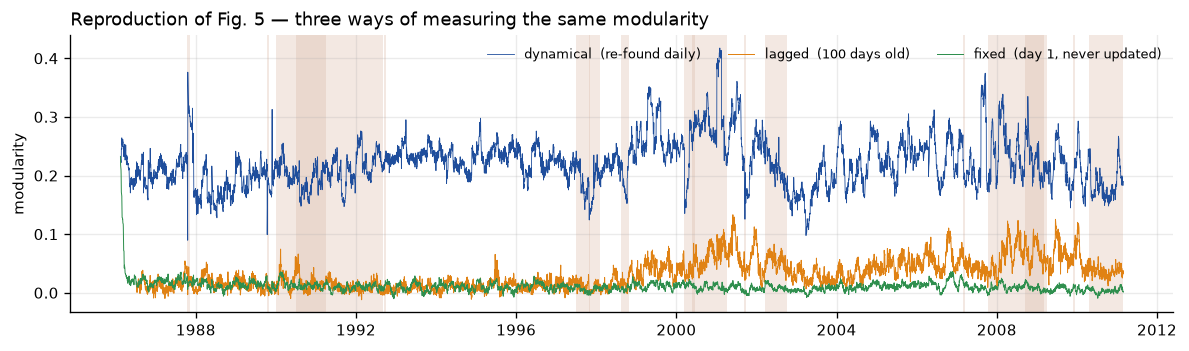

average modularity over the 25 years    dynamical 0.222   lagged 0.031   fixed 0.011
fixed modularity, first year of the sample   0.031
fixed modularity, last year of the sample    0.004

The paper and this run agree on the direction: the fixed and lagged curves sit below the
dynamical one and their spikes are flatter, so during a spike the market is genuinely
re-arranging which stocks group together, not just tightening existing groups.

They disagree on the size. In the paper's Fig. 5 the fixed curve stays clearly above zero for
the whole 25 years, and the text says communities 'preserve most of their membership
composition, even in very long periods after the crash'. Here the day-1 grouping is worth
almost nothing within a single year (0.031) and essentially nothing after that.
Our communities churn far faster than the paper's. That is a real disagreement, not a
plotting difference, and it is visible in the figure above as two curves pinned to the floor.


In [8]:
from utils.crisis_dates import CRISES
s_paper = P.load_series()

fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
for ax in axes:
    for c in CRISES:
        ax.axvspan(pd.Timestamp(c["start"]), pd.Timestamp(c["end"]), color="#d8b4a0", alpha=.30, lw=0)
axes[0].plot(idx, com["q_dyn"], color=C_REAL, lw=.5)
axes[0].set_ylabel("modularity")
axes[0].set_title("Reproduction of Fig. 4 — modularity and path length, with known crises shaded", loc="left")
axes[1].plot(idx, s_paper["real_path_length"], color=C_COMM, lw=.5)
axes[1].set_ylabel("average shortest path")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 3.0))
for c in CRISES:
    ax.axvspan(pd.Timestamp(c["start"]), pd.Timestamp(c["end"]), color="#d8b4a0", alpha=.30, lw=0)
ax.plot(idx, com["q_dyn"],    color=C_REAL, lw=.5, label="dynamical  (re-found daily)")
ax.plot(idx, com["q_lagged"], color=C_COMM, lw=.6, label="lagged  (100 days old)")
ax.plot(idx, com["q_fixed"],  color=C_CONF, lw=.6, label="fixed  (day 1, never updated)")
ax.set_ylabel("modularity"); ax.legend(loc="upper right", frameon=False, ncol=3, fontsize=8)
ax.set_title("Reproduction of Fig. 5 — three ways of measuring the same modularity", loc="left")
plt.tight_layout(); plt.show()

print(f"average modularity over the 25 years    dynamical {com['q_dyn'].mean():.3f}   "
      f"lagged {com['q_lagged'].mean():.3f}   fixed {com['q_fixed'].mean():.3f}")
print(f"fixed modularity, first year of the sample   {com['q_fixed'][:250].mean():.3f}")
print(f"fixed modularity, last year of the sample    {com['q_fixed'][-250:].mean():.3f}")
print()
print("The paper and this run agree on the direction: the fixed and lagged curves sit below the")
print("dynamical one and their spikes are flatter, so during a spike the market is genuinely")
print("re-arranging which stocks group together, not just tightening existing groups.")
print()
print("They disagree on the size. In the paper's Fig. 5 the fixed curve stays clearly above zero for")
print("the whole 25 years, and the text says communities 'preserve most of their membership")
print("composition, even in very long periods after the crash'. Here the day-1 grouping is worth")
print(f"almost nothing within a single year ({com['q_fixed'][:250].mean():.3f}) and essentially nothing after that.")
print("Our communities churn far faster than the paper's. That is a real disagreement, not a")
print("plotting difference, and it is visible in the figure above as two curves pinned to the floor.")

---
## Step 4 — The two random networks the paper compares against

**The community model (the paper's Eq. 2).** Take the day's communities. Count Π_αβ, the number of links
running between community α and community β. Turn those counts into probabilities by dividing by how many
pairs *could* have been linked:

$$\pi_{\alpha\beta}=\frac{2\,\Pi_{\alpha\alpha}}{|\alpha|(|\alpha|-1)}\ \text{ if }\alpha=\beta,\qquad
\pi_{\alpha\beta}=\frac{\Pi_{\alpha\beta}}{|\alpha||\beta|}\ \text{ otherwise.}$$

Then start from a pile of unconnected stocks, put them into communities of the observed sizes, and link
each pair with a coin flip weighted by π. That is the whole model — community sizes and Π, nothing else.

**The degree model (configuration model).** Keep how many links each stock has and shuffle everything
else. This is the yardstick: anything this model already reproduces is explained by connection counts
alone and says nothing about communities.

One realisation of each, per day, exactly as the paper describes.

In [9]:
store = MixingStore.load(os.path.join(ROOT, "data", "mixing.npz"))
Pi, sizes = store[w]
pi = block_probabilities(Pi, sizes)

rng = np.random.default_rng(42)
g_comm, _ = community_graph(sizes, Pi, rng, N)
g_conf, _ = configuration_graph(g, 42 + 7)

rows = pd.DataFrame({
    "real network":    [g.ecount(), f"{np.mean(g.degree()):.1f}", f"{g.modularity(g.community_multilevel().membership):.3f}"],
    "community model": [g_comm.ecount(), f"{np.mean(g_comm.degree()):.1f}", f"{g_comm.modularity(g_comm.community_multilevel().membership):.3f}"],
    "degree model":    [g_conf.ecount(), f"{np.mean(g_conf.degree()):.1f}", f"{g_conf.modularity(g_conf.community_multilevel().membership):.3f}"],
}, index=["links", "average links per stock", "modularity"])
print(f"one day ({date.date()}), all three networks\n")
print(rows.to_string())
print(f"\nthat day had {len(sizes)} communities, the largest holding {sizes.max()} stocks")
print(f"the community model is described by {len(sizes) + len(sizes)*(len(sizes)+1)//2} numbers; "
      f"the degree model by {N}")

one day (1990-11-12), all three networks

                        real network community model degree model
links                           6462            6419         6462
average links per stock         35.9            35.7         35.9
modularity                     0.174           0.176        0.097

that day had 14 communities, the largest holding 78 stocks
the community model is described by 119 numbers; the degree model by 360


---
## Step 5 — Eight measurements, three networks, every day

The paper measures eight properties of each network: modularity, average shortest path, degree
assortativity, transitivity, average betweenness, clique number, rich-club coefficient and average
matching index. It does this for the real network and for both random models, on all ~6,000 days.

Two places where the paper does not say what it means, and what was chosen here:

- **Average shortest path on a broken-up network.** Some days the network is in pieces and there is no
  path between some stocks. Those pairs are skipped rather than treated as infinitely far apart.
- **Matching index.** The paper cites Costa et al. (2007), where it is defined *per link*: of all the
  neighbours two connected stocks have, what fraction do they share. It is averaged over links here.
  (Averaging the same quantity over all pairs instead gives ~0.065, far below the 0.10–0.40 range the
  paper's own figure axis shows; the per-link version gives ~0.19, inside it.)

The cell below runs the whole thing and caches it, so it is instant on a re-run.

In [10]:
rep = P.run(verbose=True)
s = P.load_series()
print(f"\n{rep['n_windows']:,} days x (1 real + 1 community + 1 degree) = "
      f"{3*rep['n_windows']:,} network measurements, {rep['elapsed_sec']:.0f}s")
print(f"one realisation of each model per day, as in the paper; seed {rep['seed']}\n")
print(s[[f"real_{m}" for m in P.MEASURES]].describe().loc[["mean","std","min","max"]].round(3).to_string())

[cached] /Users/jash/Financial_networks_project/paper3_market_modularity/results/paper_only.json — pass force=True to rebuild.

6,315 days x (1 real + 1 community + 1 degree) = 18,945 network measurements, 164s
one realisation of each model per day, as in the paper; seed 42

      real_modularity  real_path_length  real_assortativity  real_transitivity  real_betweenness  real_clique_number  real_rich_club  real_matching_index
mean            0.221             2.283               0.206              0.429           209.908              23.404           0.617                0.194
std             0.041             0.128               0.110              0.086            28.724               7.797           0.101                0.040
min             0.089             1.928              -0.160              0.249            55.483               9.000           0.252                0.119
max             0.416             3.110               0.435              0.716           318.417            

---
## Step 6 — Reproducing Fig. 6

For each measure the paper shows two panels: the three time series on the left, and a scatter of the real
value against each model's value on the right. On the scatter, the diagonal line is perfect agreement —
points on the line mean the model got that day exactly right.

It then reports two numbers per model per period:

- **χ²** — the average squared difference. Small = the model lands on the same *value*.
- **ρ** — the Pearson correlation. High = the model *moves the same way* over time, even if it sits at a
  different level.

The split at 2002 is the paper's own: it noticed the market behaves differently after that year.

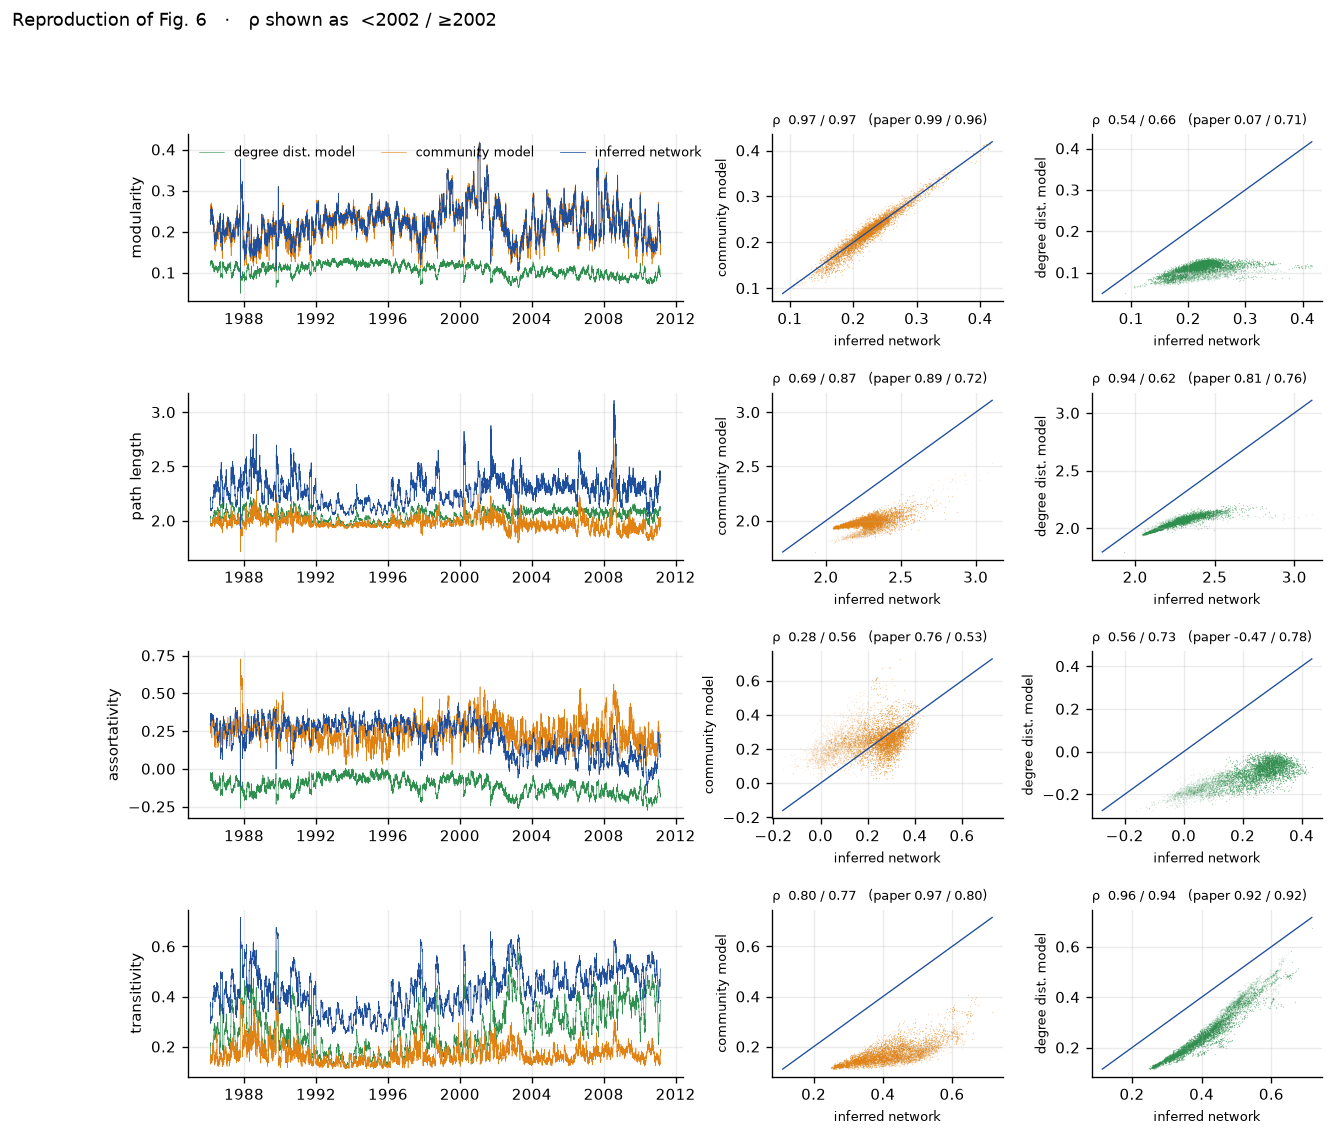

In [11]:
def panel(measures, figtitle):
    t = P.load_table()
    fig = plt.figure(figsize=(12.2, 2.55*len(measures)))
    gs = fig.add_gridspec(len(measures), 3, width_ratios=[2.15, 1, 1], hspace=.55, wspace=.28)
    for r, m in enumerate(measures):
        ax = fig.add_subplot(gs[r, 0])
        ax.plot(s.index, s[f"conf_{m}"], color=C_CONF, lw=.35, label="degree dist. model")
        ax.plot(s.index, s[f"comm_{m}"], color=C_COMM, lw=.35, label="community model")
        ax.plot(s.index, s[f"real_{m}"], color=C_REAL, lw=.45, label="inferred network")
        ax.set_ylabel(m.replace("_", " "));
        if r == 0: ax.legend(loc="upper left", frameon=False, ncol=3, fontsize=7.5)
        for c, mod, col in [(1, "comm", C_COMM), (2, "conf", C_CONF)]:
            a = fig.add_subplot(gs[r, c])
            pre = s.index.year < 2002
            a.scatter(s[f"real_{m}"][pre], s[f"{mod}_{m}"][pre], s=.6, color=col, alpha=.35, linewidths=0)
            a.scatter(s[f"real_{m}"][~pre], s[f"{mod}_{m}"][~pre], s=.6, color=col, alpha=.12, linewidths=0)
            lo = float(min(s[f"real_{m}"].min(), s[f"{mod}_{m}"].min()))
            hi = float(max(s[f"real_{m}"].max(), s[f"{mod}_{m}"].max()))
            a.plot([lo, hi], [lo, hi], color=C_REAL, lw=.8)
            a.set_xlabel("inferred network", fontsize=7.5)
            a.set_ylabel(MODELS_LABEL[mod], fontsize=7.5)
            q = t[(t.measure == m) & (t.model == mod)].set_index("era")
            a.set_title(f"ρ  {q.loc['pre','rho']:.2f} / {q.loc['post','rho']:.2f}"
                        f"   (paper {q.loc['pre','paper_rho']:.2f} / {q.loc['post','paper_rho']:.2f})",
                        fontsize=7.5, loc="left")
    fig.suptitle(figtitle, x=.005, ha="left", fontsize=11)
    plt.show()

MODELS_LABEL = {"comm": "community model", "conf": "degree dist. model"}
panel(["modularity", "path_length", "assortativity", "transitivity"],
      "Reproduction of Fig. 6   ·   ρ shown as  <2002 / ≥2002")

In [12]:
def paper_tables(measures):
    t = P.load_table()
    for m in measures:
        q = t[t.measure == m].pivot_table(index="model", columns="era",
                                          values=["chi2","paper_chi2","rho","paper_rho"])
        out = pd.DataFrame({
            ("χ² <2002","ours"): q[("chi2","pre")],   ("χ² <2002","paper"): q[("paper_chi2","pre")],
            ("χ² ≥2002","ours"): q[("chi2","post")],  ("χ² ≥2002","paper"): q[("paper_chi2","post")],
            ("ρ <2002","ours"):  q[("rho","pre")],    ("ρ <2002","paper"):  q[("paper_rho","pre")],
            ("ρ ≥2002","ours"):  q[("rho","post")],   ("ρ ≥2002","paper"):  q[("paper_rho","post")],
        }).rename(index=MODELS_LABEL)
        print(f"\n{m}")
        print(out.to_string(float_format=lambda v: f"{v:9.4g}"))

paper_tables(["modularity", "path_length", "assortativity", "transitivity"])


modularity
                    χ² <2002            χ² ≥2002             ρ <2002             ρ ≥2002          
                        ours     paper      ours     paper      ours     paper      ours     paper
model                                                                                             
community model    0.0001208    0.0003 0.0001019    0.0002    0.9688      0.99    0.9738      0.96
degree dist. model   0.01352    0.0295   0.01623     0.012    0.5403      0.07    0.6637      0.71

path_length
                    χ² <2002            χ² ≥2002             ρ <2002             ρ ≥2002          
                        ours     paper      ours     paper      ours     paper      ours     paper
model                                                                                             
community model      0.08372    0.0189     0.136    0.1152    0.6893      0.89    0.8701      0.72
degree dist. model    0.0535    0.0333   0.06631    0.0688    0.9393      0.81    0.

---
## Step 7 — Reproducing Fig. S3

The other four measures, from the paper's supplementary material.

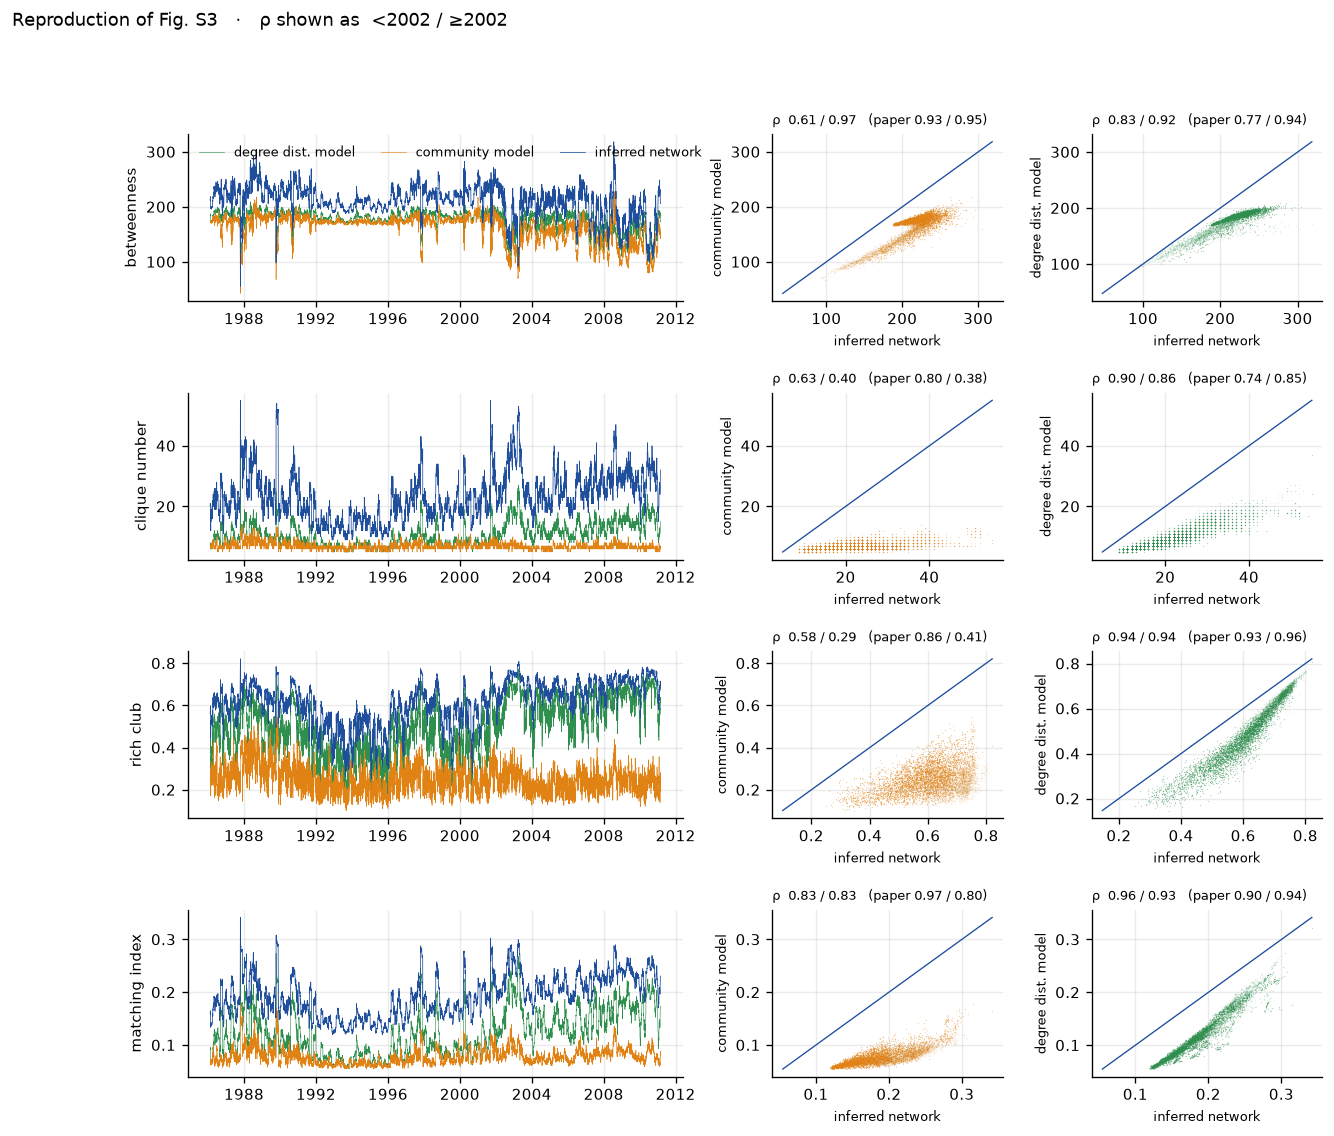


betweenness
                    χ² <2002            χ² ≥2002             ρ <2002             ρ ≥2002          
                        ours     paper      ours     paper      ours     paper      ours     paper
model                                                                                             
community model         2393       419      3014      2522    0.6112      0.93    0.9698      0.95
degree dist. model      1465       691      1301      1095    0.8337      0.77    0.9172      0.94

clique_number
                    χ² <2002            χ² ≥2002             ρ <2002             ρ ≥2002          
                        ours     paper      ours     paper      ours     paper      ours     paper
model                                                                                             
community model        238.7       191     478.9       552    0.6282       0.8    0.4035      0.38
degree dist. model     164.6       203     216.6       259    0.9023      0.74   

In [13]:
panel(["betweenness", "clique_number", "rich_club", "matching_index"],
      "Reproduction of Fig. S3   ·   ρ shown as  <2002 / ≥2002")
paper_tables(["betweenness", "clique_number", "rich_club", "matching_index"])

---
## Step 8 — Reproducing Fig. 7 (PCA)

Eight measures is a lot to look at. The paper compresses them into two numbers per network with Principal
Component Analysis, and plots all three families of network in that plane. If the community model's cloud
sits on top of the real one, the model is reproducing the market's whole topological signature at once.

The paper reads this plot in a specific way, worth quoting: *"the first principal component (PCA1) is
strongly related to changes in the network structure along time... Therefore, the models should be
compared according to the second principal component (PCA2)."*

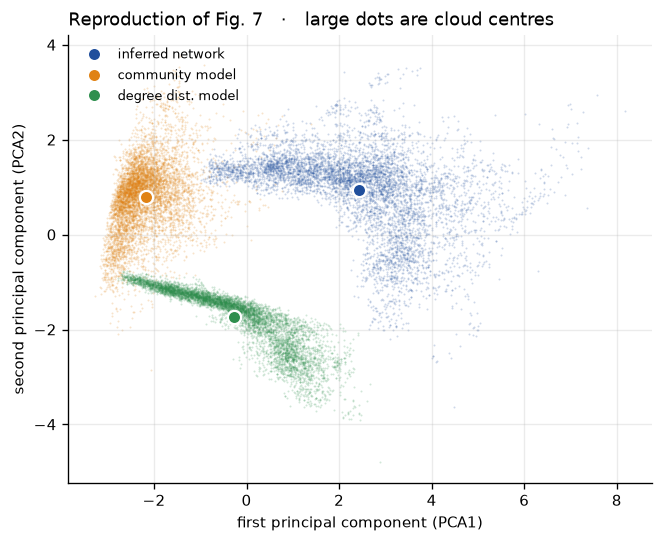

distance from the inferred network's centre:
  community model      along PCA2 (the paper's criterion)  0.14     in the full plane  4.62
  degree dist. model   along PCA2 (the paper's criterion)  2.67     in the full plane  3.80


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = np.vstack([np.column_stack([s[f"{fam}_{m}"] for m in P.MEASURES])
               for fam in ("real", "comm", "conf")])
fam = np.repeat(["real", "comm", "conf"], len(s))
ok = np.isfinite(X).all(1)
Z = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X[ok]))
fam = fam[ok]

fig, ax = plt.subplots(figsize=(5.6, 4.6))
for f, col, lab in [("real", C_REAL, "inferred network"), ("comm", C_COMM, "community model"),
                    ("conf", C_CONF, "degree dist. model")]:
    ax.scatter(Z[fam == f, 0], Z[fam == f, 1], s=1.4, color=col, alpha=.22, linewidths=0)
    c = Z[fam == f].mean(0)
    ax.plot(*c, "o", ms=8, mfc=col, mec="white", mew=1.4, label=lab, zorder=5)
ax.set_xlabel("first principal component (PCA1)"); ax.set_ylabel("second principal component (PCA2)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.set_title("Reproduction of Fig. 7   ·   large dots are cloud centres", loc="left")
plt.tight_layout(); plt.show()

cen = {f: Z[fam == f].mean(0) for f in ("real", "comm", "conf")}
print("distance from the inferred network's centre:")
for f, lab in [("comm", "community model"), ("conf", "degree dist. model")]:
    print(f"  {lab:<20} along PCA2 (the paper's criterion) {abs(cen[f][1]-cen['real'][1]):5.2f}"
          f"     in the full plane {np.hypot(*(cen[f]-cen['real'])):5.2f}")

---
## Step 9 — All 32 of the paper's numbers, side by side

The paper publishes 32 combinations — 8 measures × 2 models × 2 periods — each with a χ² and a ρ.
Here they all are against ours. The last column is ours minus the paper's correlation; near zero means
reproduced, and anything past 0.30 is flagged.

In [15]:
t = P.load_table()
print(f"{'measure':<15}{'model':<7}{'era':<6}{'χ² ours':>11}{'χ² paper':>11}"
      f"{'ρ ours':>9}{'ρ paper':>9}{'Δρ':>8}   ")
print("-"*79)
for _, x in t.iterrows():
    flag = "  <-- differs" if abs(x["rho_delta"]) > 0.30 else ""
    print(f"{x['measure']:<15}{MODELS_LABEL[x['model']][:6]:<7}{x['era']:<6}"
          f"{x['chi2']:>11.4g}{x['paper_chi2']:>11.4g}"
          f"{x['rho']:>9.3f}{x['paper_rho']:>9.2f}{x['rho_delta']:>+8.2f}{flag}")

r, h = rep["rho"], rep["head_to_head"]
print(f"\nAgreement across all 32 correlations:")
print(f"  average gap to the paper        {r['mae_vs_paper']:.3f}")
print(f"  within 0.10 of the paper        {r['within_0_10']:.0%}")
print(f"  within 0.30 of the paper        {r['within_0_30']:.0%}")
print(f"  same sign as the paper          {r['sign_agreement']:.0%}")

measure        model  era       χ² ours   χ² paper   ρ ours  ρ paper      Δρ   
-------------------------------------------------------------------------------
modularity     commun pre     0.0001208     0.0003    0.969     0.99   -0.02
modularity     commun post    0.0001019     0.0002    0.974     0.96   +0.01
modularity     degree pre       0.01352     0.0295    0.540     0.07   +0.47  <-- differs
modularity     degree post      0.01623      0.012    0.664     0.71   -0.05
path_length    commun pre       0.08372     0.0189    0.689     0.89   -0.20
path_length    commun post        0.136     0.1152    0.870     0.72   +0.15
path_length    degree pre        0.0535     0.0333    0.939     0.81   +0.13
path_length    degree post      0.06631     0.0688    0.617     0.76   -0.14
assortativity  commun pre      0.007697      0.012    0.283     0.76   -0.48  <-- differs
assortativity  commun post      0.02478     0.0259    0.562     0.53   +0.03
assortativity  degree pre        0.1327     

In [16]:
print("Which model is closer to the real network, counted over the 16 measure x period cells?\n")
print(f"{'':<26}{'community model wins':>22}{'degree model wins':>20}")
print(f"{'by χ²   the paper':<26}{h['paper_community_wins_chi2']:>22}{16-h['paper_community_wins_chi2']:>20}")
print(f"{'by χ²   this run':<26}{h['ours_community_wins_chi2']:>22}{16-h['ours_community_wins_chi2']:>20}")
print(f"{'by ρ    the paper':<26}{h['paper_community_wins_rho']:>22}{16-h['paper_community_wins_rho']:>20}")
print(f"{'by ρ    this run':<26}{h['ours_community_wins_rho']:>22}{16-h['ours_community_wins_rho']:>20}")

Which model is closer to the real network, counted over the 16 measure x period cells?

                            community model wins   degree model wins
by χ²   the paper                              8                   8
by χ²   this run                               4                  12
by ρ    the paper                              9                   7
by ρ    this run                               4                  12


---
## Step 10 — What reproduced and what did not

**Reproduced.**

- Fixing the density really does hold the average number of links per stock exactly constant, every day.
- Black Monday behaves as the paper describes: modularity collapses to the lowest value in 25 years and
  the network breaks into a dense core plus a crowd of disconnected stocks.
- The community model reproduces the real network's modularity almost perfectly — the headline claim, and
  the strongest single result in the paper.
- The degree model's modularity sits near 0.10, the flat floor the paper draws but never states in words.
- Across all 32 published values, the signs agree almost everywhere and most correlations land close.

**Did not reproduce.**

- The persistence of the communities (Fig. 5). The paper's fixed and lagged modularity stay well clear of
  zero for 25 years; ours collapse within the first year. The paper's groups last, ours do not.
- The cells flagged in the table above. They concentrate in the degree-distribution model, which in this run
tracks the real network *more* closely than it does in the paper. That matters, because the degree model is
the yardstick: the community model looks good in proportion to how badly the degree model does.

**What could not be matched at all.** The stock list. The paper's 348 NYSE names were chosen from a 2015
snapshot of 3,799 listings; that snapshot is gone, and any list assembled today is filtered by survival.
Everything in this notebook rests on a different, slightly larger sample of the same market over the same
years, and no amount of care in the code closes that gap.